# Exercise 7 — The Newton Method

This notebook solves **Exercise Sheet 7: The Newton Method** in a simple, human-style Python way.

I avoid complicated class structures here.  
Everything is written with normal Python functions, so that the idea is easy to follow.

## Main idea

Newton's method tries to solve

\[
\nabla f(x)=0
\]

At the current point \(x_k\), we use a Taylor approximation of the gradient:

\[
\nabla f(x_k+d_k) \approx \nabla f(x_k)+\nabla^2 f(x_k)d_k
\]

We want the new gradient to become zero:

\[
\nabla f(x_k)+\nabla^2 f(x_k)d_k = 0
\]

So we solve

\[
\nabla^2 f(x_k)d_k = -\nabla f(x_k)
\]

Then we update

\[
x_{k+1}=x_k+d_k
\]

The exercise asks us to solve this inner linear system using the **Conjugate Gradient method**.

## 1. Import libraries

We use only basic scientific Python tools:

- `numpy` for vectors and matrices
- `matplotlib` for plots
- `scipy.sparse.diags` for the tridiagonal matrix
- `scipy.sparse.linalg.spsolve` only to check the exact solution in one quadratic test

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

np.random.seed(0)

# Part A — Small helper functions

Before writing Newton's method, we prepare a few simple helper functions.

## 2. Tridiagonal matrix \(T_n\)

The exercise uses

\[
Q=T_n
\]

with

- `2` on the main diagonal
- `-1` on the upper diagonal
- `-1` on the lower diagonal

This matrix is symmetric positive definite.

In [2]:
def create_tridiagonal_matrix(n, dense=False):
    """
    Create the tridiagonal matrix T_n.

    If dense=False, we return a sparse matrix.
    If dense=True, we return a normal NumPy matrix.
    """
    main_diagonal = 2 * np.ones(n)
    off_diagonal = -1 * np.ones(n - 1)

    Q_sparse = diags(
        diagonals=[off_diagonal, main_diagonal, off_diagonal],
        offsets=[-1, 0, 1],
        format="csr"
    )

    if dense:
        return Q_sparse.toarray()

    return Q_sparse

In [3]:
Q_test = create_tridiagonal_matrix(5, dense=True)
print(Q_test)

[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]


## 3. Conjugate Gradient solver for linear systems

In Exercise 6, CG was used to minimize a quadratic function.

Here, inside Newton's method, we use CG to solve a linear system:

\[
A d = b
\]

For Newton's method:

\[
A = \nabla^2 f(x_k)
\]

and

\[
b = -\nabla f(x_k)
\]

So the unknown vector is the Newton direction \(d_k\).

In [4]:
def cg_linear_solver(A, b, x0=None, tol=1e-10, maxit=2000):
    """
    Simple Conjugate Gradient solver for A x = b.

    This is written for symmetric positive definite matrices.
    """

    n = len(b)

    if x0 is None:
        x = np.zeros(n)
    else:
        x = x0.copy()

    r = b - A @ x
    d = r.copy()

    res = np.linalg.norm(r)
    residuals = [res]

    k = 0

    while res > tol and k < maxit:
        A_d = A @ d
        denominator = d @ A_d

        if abs(denominator) < 1e-30:
            break

        alpha = (r @ r) / denominator

        x = x + alpha * d
        r_new = r - alpha * A_d

        res_new = np.linalg.norm(r_new)
        residuals.append(res_new)

        if res_new < tol:
            k = k + 1
            break

        beta = (r_new @ r_new) / (r @ r)

        d = r_new + beta * d
        r = r_new
        res = res_new

        k = k + 1

    return x, residuals, k

# Part B — Newton method

Now we implement Newton's method.

The function needs:

- `f(x)` — function value
- `grad(x)` — gradient
- `hess(x)` — Hessian matrix
- `x0` — starting value

At each Newton iteration we solve:

\[
\nabla^2 f(x_k)d_k = -\nabla f(x_k)
\]

with our CG solver.

In [5]:
def newton_method(f, grad, hess, x0, tol=1e-8, maxit=30, cg_tol=1e-10, cg_maxit=2000):
    """
    Simple Newton method.

    The Newton direction is found by solving:

        Hessian(x) * d = -gradient(x)

    using the CG solver above.
    """

    x = x0.copy().astype(float)

    residuals = []
    linear_iterations = []

    for k in range(maxit):
        g = grad(x)
        res = np.linalg.norm(g)

        residuals.append(res)

        if res < tol:
            break

        H = hess(x)

        # Solve H d = -g
        d, cg_residuals, cg_iterations = cg_linear_solver(
            H,
            -g,
            tol=cg_tol,
            maxit=cg_maxit
        )

        linear_iterations.append(cg_iterations)

        # Newton update
        x = x + d

    return x, residuals, linear_iterations

# Task 2(a) — Quadratic problem

The quadratic function is

\[
f(x)=\frac{1}{2}x^TQx+p^Tx+c
\]

The gradient is

\[
\nabla f(x)=Qx+p
\]

The Hessian is

\[
\nabla^2 f(x)=Q
\]

For a quadratic function, Newton's method should need only **one Newton iteration**, because the Hessian is constant.

In [6]:
def quadratic_function_factory(Q, p, c=0.0):
    """
    Return f, grad, and hess for the quadratic function.
    """

    def f(x):
        return 0.5 * x @ (Q @ x) + p @ x + c

    def grad(x):
        return Q @ x + p

    def hess(x):
        return Q

    return f, grad, hess

In [7]:
n = 20

Q = create_tridiagonal_matrix(n)
p = np.ones(n)
x0 = np.zeros(n)

f_quad, grad_quad, hess_quad = quadratic_function_factory(Q, p)

x_newton, res_newton, lin_iters = newton_method(
    f_quad,
    grad_quad,
    hess_quad,
    x0,
    tol=1e-8,
    maxit=10,
    cg_tol=1e-12,
    cg_maxit=100
)

x_exact = spsolve(Q, -p)

print("Number of Newton iterations:", len(res_newton) - 1)
print("Final residual:", res_newton[-1])
print("Linear CG iterations inside Newton:", lin_iters)
print("Error compared with exact solution:", np.linalg.norm(x_newton - x_exact))

Number of Newton iterations: 1
Final residual: 0.0
Linear CG iterations inside Newton: [10]
Error compared with exact solution: 1.1374233532693354e-14


## Observation for the quadratic problem

Newton's method solves the quadratic problem in one Newton iteration.

This happens because the Hessian is constant:

\[
\nabla^2 f(x)=Q
\]

So Newton directly solves the exact optimality condition:

\[
Qx+p=0
\]

# Task 2(b) — Himmelblau function

The Himmelblau function is

\[
f(x_1,x_2)=
(x_1^2+x_2-11)^2+(x_1+x_2^2-7)^2
\]

It has several minima.

The exercise asks us to use the starting value:

\[
x_0=(20,0)^T
\]

We compare Newton's method with the Malitsky-Mishchenko gradient method.

In [8]:
def himmelblau_f(x):
    x1 = x[0]
    x2 = x[1]

    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2


def himmelblau_grad(x):
    x1 = x[0]
    x2 = x[1]

    df_dx1 = 4*x1*(x1**2 + x2 - 11) + 2*(x1 + x2**2 - 7)
    df_dx2 = 2*(x1**2 + x2 - 11) + 4*x2*(x1 + x2**2 - 7)

    return np.array([df_dx1, df_dx2], dtype=float)


def himmelblau_hess(x):
    x1 = x[0]
    x2 = x[1]

    h11 = 12*x1**2 + 4*x2 - 42
    h12 = 4*x1 + 4*x2
    h22 = 12*x2**2 + 4*x1 - 26

    return np.array([
        [h11, h12],
        [h12, h22]
    ], dtype=float)

## Malitsky-Mishchenko method

This is an adaptive gradient method.

It estimates a useful step size automatically.

We keep the implementation simple and general, so we can reuse it for several functions.

In [9]:
def malitsky_mishchenko_method(grad, x0, tol=1e-8, maxit=20000):
    """
    Simple Malitsky-Mishchenko method.

    This method only needs the gradient.
    It automatically changes the step size.
    """

    alpha_old = 1e-16
    theta_old = 1e16

    x_old = x0.copy().astype(float)
    x = x_old - alpha_old * grad(x_old)

    residuals = [np.linalg.norm(grad(x))]
    step_sizes = [alpha_old]

    for k in range(1, maxit + 1):
        g = grad(x)
        g_old = grad(x_old)

        difference_x = np.linalg.norm(x - x_old)
        difference_g = np.linalg.norm(g - g_old)

        first_choice = np.sqrt(1 + theta_old) * alpha_old

        if difference_g == 0:
            second_choice = first_choice
        else:
            second_choice = difference_x / (2 * difference_g)

        alpha = min(first_choice, second_choice)

        if alpha <= 0 or not np.isfinite(alpha):
            alpha = 1e-6

        x_new = x - alpha * g

        res = np.linalg.norm(grad(x_new))

        residuals.append(res)
        step_sizes.append(alpha)

        if res < tol:
            x = x_new
            break

        theta_old = alpha / alpha_old
        alpha_old = alpha

        x_old = x
        x = x_new

    return x, residuals, step_sizes

In [10]:
x0_himmelblau = np.array([20.0, 0.0])

x_newton_h, res_newton_h, lin_iters_h = newton_method(
    himmelblau_f,
    himmelblau_grad,
    himmelblau_hess,
    x0_himmelblau,
    tol=1e-8,
    maxit=50,
    cg_tol=1e-12,
    cg_maxit=20
)

x_mm_h, res_mm_h, steps_mm_h = malitsky_mishchenko_method(
    himmelblau_grad,
    x0_himmelblau,
    tol=1e-8,
    maxit=20000
)

print("Newton result:", x_newton_h)
print("Newton function value:", himmelblau_f(x_newton_h))
print("Newton iterations:", len(res_newton_h) - 1)
print("Newton final residual:", res_newton_h[-1])
print()

print("Malitsky-Mishchenko result:", x_mm_h)
print("Malitsky-Mishchenko function value:", himmelblau_f(x_mm_h))
print("Malitsky-Mishchenko iterations:", len(res_mm_h) - 1)
print("Malitsky-Mishchenko final residual:", res_mm_h[-1])

Newton result: [ 3.58442834 -1.84812653]
Newton function value: 1.476747614573734e-26
Newton iterations: 9
Newton final residual: 1.5663904194712175e-12

Malitsky-Mishchenko result: [ 3.58442834 -1.84812653]
Malitsky-Mishchenko function value: 8.238638529638767e-19
Malitsky-Mishchenko iterations: 56
Malitsky-Mishchenko final residual: 6.937143722067988e-09


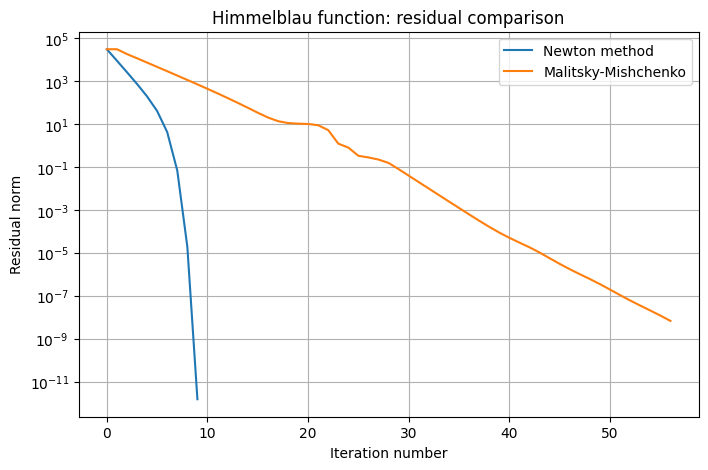

In [11]:
plt.figure(figsize=(8, 5))

plt.semilogy(res_newton_h, label="Newton method")
plt.semilogy(res_mm_h, label="Malitsky-Mishchenko")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("Himmelblau function: residual comparison")
plt.legend()
plt.grid(True)
plt.show()

## Observation for Himmelblau

Newton's method is much faster here.

Why?

Because Newton uses curvature information from the Hessian matrix.

The Malitsky-Mishchenko method only uses gradients, so it usually needs more iterations.

However, Newton's method is more expensive per iteration because it solves a linear system inside every Newton step.

# Task 2(c) — Functions \(f_3\) and \(f_4\)

We use

\[
f_3(x)=\sqrt{1+x^TQx}
\]

and

\[
f_4(x)=f_3(x)+\frac{1}{2}x^TQx
\]

The starting value is

\[
x_0 = \lambda [1,1,\dots,1]^T
\]

with

\[
\lambda \in [0.1,2]
\]

We use \(n=20\).

Important:

- \(f_3\) is convex, but not strongly convex globally.
- \(f_4\) is better behaved because of the extra quadratic term.
- Heavy-ball needs \(\mu\) and \(L\), so we use it for \(f_4\), but not for \(f_3\).

In [12]:
def f3_factory(Q):
    """
    f3(x) = sqrt(1 + x^T Q x)
    """

    def f(x):
        return np.sqrt(1 + x @ (Q @ x))

    def grad(x):
        s = np.sqrt(1 + x @ (Q @ x))
        return (Q @ x) / s

    def hess(x):
        qx = Q @ x
        s = np.sqrt(1 + x @ qx)

        return Q / s - np.outer(qx, qx) / (s**3)

    return f, grad, hess


def f4_factory(Q):
    """
    f4(x) = f3(x) + 1/2 x^T Q x
    """

    f3, grad3, hess3 = f3_factory(Q)

    def f(x):
        return f3(x) + 0.5 * x @ (Q @ x)

    def grad(x):
        return grad3(x) + Q @ x

    def hess(x):
        return hess3(x) + Q

    return f, grad, hess

## Heavy-ball method

We use this only when \(\mu\) and \(L\) are available.

For \(f_4\), a simple practical choice is

\[
\mu \approx \lambda_{\min}(Q)
\]

and

\[
L \approx 2\lambda_{\max}(Q)
\]

In [13]:
def heavy_ball_method(grad, x0, mu, L, tol=1e-8, maxit=10000):
    """
    Simple heavy-ball method.
    """

    alpha = 4 / (np.sqrt(L) + np.sqrt(mu))**2
    beta = ((np.sqrt(L) - np.sqrt(mu)) / (np.sqrt(L) + np.sqrt(mu)))**2

    x_old = x0.copy().astype(float)
    x = x_old - alpha * grad(x_old)

    residuals = [
        np.linalg.norm(grad(x_old)),
        np.linalg.norm(grad(x))
    ]

    step_sizes = [alpha, alpha]

    for k in range(maxit):
        if residuals[-1] < tol:
            break

        x_new = x - alpha * grad(x) + beta * (x - x_old)

        x_old = x
        x = x_new

        residuals.append(np.linalg.norm(grad(x)))
        step_sizes.append(alpha)

        if not np.isfinite(residuals[-1]):
            break

    return x, residuals, step_sizes

In [14]:
n = 20
Q_dense = create_tridiagonal_matrix(n, dense=True)

f3, grad3, hess3 = f3_factory(Q_dense)
f4, grad4, hess4 = f4_factory(Q_dense)

eigenvalues = np.linalg.eigvalsh(Q_dense)
mu_Q = eigenvalues[0]
L_Q = eigenvalues[-1]

print("lambda_min(Q) =", mu_Q)
print("lambda_max(Q) =", L_Q)

lambda_min(Q) = 0.02233834754974316
lambda_max(Q) = 3.9776616524502573


## Compare \(f_3\) and \(f_4\)

To keep the notebook readable, we test a few representative values of \(\lambda\):

\[
0.1,\ 0.5,\ 1.0,\ 1.5,\ 2.0
\]

In [15]:
lambda_values = [0.1, 0.5, 1.0, 1.5, 2.0]

results_f3 = []
results_f4 = []

for lam in lambda_values:
    x0 = lam * np.ones(n)

    # f3: Newton
    x_newton_3, res_newton_3, lin_3 = newton_method(
        f3,
        grad3,
        hess3,
        x0,
        tol=1e-8,
        maxit=50,
        cg_tol=1e-10,
        cg_maxit=100
    )

    # f3: Malitsky-Mishchenko
    x_mm_3, res_mm_3, step_mm_3 = malitsky_mishchenko_method(
        grad3,
        x0,
        tol=1e-8,
        maxit=20000
    )

    results_f3.append({
        "lambda": lam,
        "Newton iterations": len(res_newton_3) - 1,
        "Newton final residual": res_newton_3[-1],
        "MM iterations": len(res_mm_3) - 1,
        "MM final residual": res_mm_3[-1],
        "Newton ||x||": np.linalg.norm(x_newton_3)
    })

    # f4: Newton
    x_newton_4, res_newton_4, lin_4 = newton_method(
        f4,
        grad4,
        hess4,
        x0,
        tol=1e-8,
        maxit=50,
        cg_tol=1e-10,
        cg_maxit=100
    )

    # f4: Malitsky-Mishchenko
    x_mm_4, res_mm_4, step_mm_4 = malitsky_mishchenko_method(
        grad4,
        x0,
        tol=1e-8,
        maxit=20000
    )

    # f4: Heavy-ball
    x_hb_4, res_hb_4, step_hb_4 = heavy_ball_method(
        grad4,
        x0,
        mu=mu_Q,
        L=2*L_Q,
        tol=1e-8,
        maxit=20000
    )

    results_f4.append({
        "lambda": lam,
        "Newton iterations": len(res_newton_4) - 1,
        "Newton final residual": res_newton_4[-1],
        "MM iterations": len(res_mm_4) - 1,
        "MM final residual": res_mm_4[-1],
        "Heavy-ball iterations": len(res_hb_4) - 1,
        "Heavy-ball final residual": res_hb_4[-1]
    })

In [16]:
print("Results for f3")
print("-" * 80)

for row in results_f3:
    print(row)

print()
print("Results for f4")
print("-" * 80)

for row in results_f4:
    print(row)

Results for f3
--------------------------------------------------------------------------------
{'lambda': 0.1, 'Newton iterations': 3, 'Newton final residual': np.float64(4.655785177606943e-23), 'MM iterations': 774, 'MM final residual': np.float64(9.742822961953202e-09), 'Newton ||x||': np.float64(1.2694460342895791e-22)}
{'lambda': 0.5, 'Newton iterations': 4, 'Newton final residual': np.float64(6.448980801555932e-13), 'MM iterations': 885, 'MM final residual': np.float64(9.943431696896932e-09), 'Newton ||x||': np.float64(2.033727980462329e-12)}
{'lambda': 1.0, 'Newton iterations': 49, 'Newton final residual': np.float64(1.0645175273626948), 'MM iterations': 896, 'MM final residual': np.float64(9.713138118899477e-09), 'Newton ||x||': np.float64(2.085037905805113e+31)}
{'lambda': 1.5, 'Newton iterations': 49, 'Newton final residual': np.float64(1.0647296667531512), 'MM iterations': 871, 'MM final residual': np.float64(9.498811474248242e-09), 'Newton ||x||': np.float64(2.5904295332539

## Plot one example for \(f_3\)

For \(f_3\), plain Newton can behave badly from larger starting values.

The reason is that \(f_3\) is not strongly convex globally.  
Far from the minimizer, the Hessian can become weak.

This can make the Newton step too aggressive.

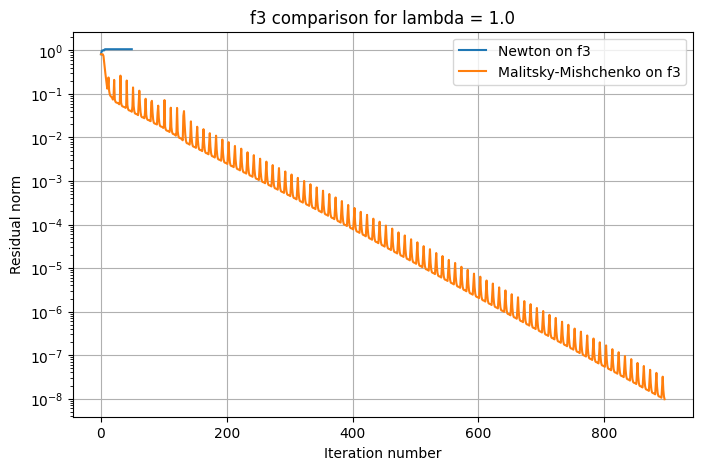

In [17]:
lam = 1.0
x0 = lam * np.ones(n)

x_newton_3, res_newton_3, lin_3 = newton_method(
    f3,
    grad3,
    hess3,
    x0,
    tol=1e-8,
    maxit=50,
    cg_tol=1e-10,
    cg_maxit=100
)

x_mm_3, res_mm_3, step_mm_3 = malitsky_mishchenko_method(
    grad3,
    x0,
    tol=1e-8,
    maxit=20000
)

plt.figure(figsize=(8, 5))

plt.semilogy(res_newton_3, label="Newton on f3")
plt.semilogy(res_mm_3, label="Malitsky-Mishchenko on f3")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("f3 comparison for lambda = 1.0")
plt.legend()
plt.grid(True)
plt.show()

## Plot one example for \(f_4\)

For \(f_4\), Newton behaves much better.

The extra quadratic term

\[
\frac12 x^TQx
\]

adds stronger curvature to the problem.

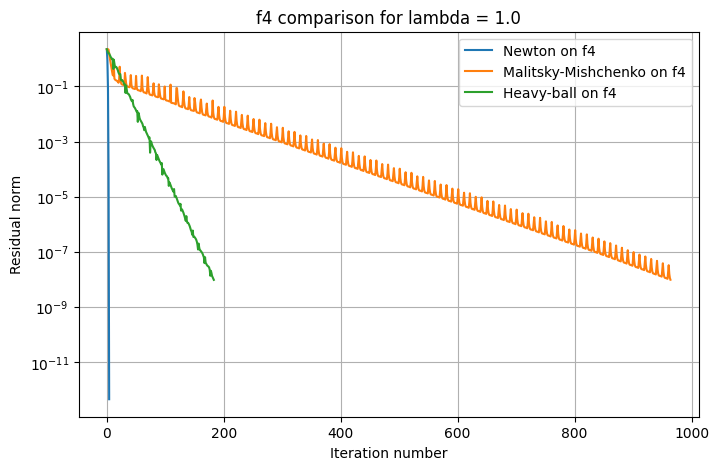

In [18]:
lam = 1.0
x0 = lam * np.ones(n)

x_newton_4, res_newton_4, lin_4 = newton_method(
    f4,
    grad4,
    hess4,
    x0,
    tol=1e-8,
    maxit=50,
    cg_tol=1e-10,
    cg_maxit=100
)

x_mm_4, res_mm_4, step_mm_4 = malitsky_mishchenko_method(
    grad4,
    x0,
    tol=1e-8,
    maxit=20000
)

x_hb_4, res_hb_4, step_hb_4 = heavy_ball_method(
    grad4,
    x0,
    mu=mu_Q,
    L=2*L_Q,
    tol=1e-8,
    maxit=20000
)

plt.figure(figsize=(8, 5))

plt.semilogy(res_newton_4, label="Newton on f4")
plt.semilogy(res_mm_4, label="Malitsky-Mishchenko on f4")
plt.semilogy(res_hb_4, label="Heavy-ball on f4")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("f4 comparison for lambda = 1.0")
plt.legend()
plt.grid(True)
plt.show()

## Observation for \(f_3\) and \(f_4\)

### For \(f_3\)

Plain Newton can fail or behave badly when \(\lambda\) is larger.

Reason:

\[
f_3(x)=\sqrt{1+x^TQx}
\]

has Hessian values that become small far away from the origin.

So Newton may take a very large step.

### For \(f_4\)

Newton works much better.

Reason:

\[
f_4(x)=f_3(x)+\frac12x^TQx
\]

has an extra quadratic part.

That makes the problem more stable and strongly curved.

# Task 2(d) — Damped Newton method

Plain Newton uses

\[
x_{k+1}=x_k+d_k
\]

Damped Newton uses

\[
x_{k+1}=x_k+s d_k
\]

where \(s\in(0,1]\).

So if the full Newton step is too large, we reduce it.

A simple line search is:

1. Start with \(s=1\)
2. Check whether the function decreases enough
3. If not, reduce

\[
s \leftarrow b s
\]

We use the standard Armijo form:

\[
f(x_k+s d_k)\le f(x_k)+a s \nabla f(x_k)^T d_k
\]

Because \(d_k\) is a descent direction, usually

\[
\nabla f(x_k)^T d_k < 0
\]

In [19]:
def damped_newton_method(
    f,
    grad,
    hess,
    x0,
    tol=1e-8,
    maxit=50,
    cg_tol=1e-10,
    cg_maxit=2000,
    a=1e-4,
    b=0.5
):
    """
    Damped Newton method with a simple backtracking line search.

    We first compute the Newton direction d.
    Then we choose a step size s <= 1.
    """

    x = x0.copy().astype(float)

    residuals = []
    linear_iterations = []
    damping_steps = []
    function_values = []

    for k in range(maxit):
        g = grad(x)
        res = np.linalg.norm(g)

        residuals.append(res)
        function_values.append(f(x))

        if res < tol:
            break

        H = hess(x)

        d, cg_residuals, cg_iterations = cg_linear_solver(
            H,
            -g,
            tol=cg_tol,
            maxit=cg_maxit
        )

        linear_iterations.append(cg_iterations)

        s = 1.0
        g_dot_d = g @ d

        # Backtracking line search
        for line_iter in range(50):
            if f(x + s*d) <= f(x) + a*s*g_dot_d:
                break

            s = b * s

        damping_steps.append(s)

        x = x + s*d

    return x, residuals, linear_iterations, damping_steps, function_values

## Damped Newton test on \(f_3\)

This is the most interesting case.

For \(f_3\) with \(\lambda=1\) or \(\lambda=2\), plain Newton can become unstable.

Damped Newton reduces the step size and becomes much safer.

In [20]:
for lam in [1.0, 2.0]:
    x0 = lam * np.ones(n)

    x_plain, res_plain, lin_plain = newton_method(
        f3,
        grad3,
        hess3,
        x0,
        tol=1e-8,
        maxit=50,
        cg_tol=1e-10,
        cg_maxit=100
    )

    x_damped, res_damped, lin_damped, damping, values = damped_newton_method(
        f3,
        grad3,
        hess3,
        x0,
        tol=1e-8,
        maxit=50,
        cg_tol=1e-10,
        cg_maxit=100,
        a=1e-4,
        b=0.5
    )

    print("lambda =", lam)
    print("Plain Newton iterations:", len(res_plain) - 1)
    print("Plain Newton final residual:", res_plain[-1])
    print("Plain Newton ||x||:", np.linalg.norm(x_plain))
    print()
    print("Damped Newton iterations:", len(res_damped) - 1)
    print("Damped Newton final residual:", res_damped[-1])
    print("Damped Newton ||x||:", np.linalg.norm(x_damped))
    print("Damping step sizes:", damping)
    print("-" * 80)

lambda = 1.0
Plain Newton iterations: 49
Plain Newton final residual: 1.0645175273626948
Plain Newton ||x||: 2.085037905805113e+31

Damped Newton iterations: 5
Damped Newton final residual: 9.18125906191242e-13
Damped Newton ||x||: 2.0403595283606403e-12
Damping step sizes: [0.5, 1.0, 1.0, 1.0, 1.0]
--------------------------------------------------------------------------------
lambda = 2.0
Plain Newton iterations: 49
Plain Newton final residual: 1.0645175273626952
Plain Newton ||x||: 2.9786255797219613e+30

Damped Newton iterations: 4
Damped Newton final residual: 6.490054323733047e-13
Damped Newton ||x||: 2.033810525911946e-12
Damping step sizes: [0.125, 1.0, 1.0, 1.0]
--------------------------------------------------------------------------------


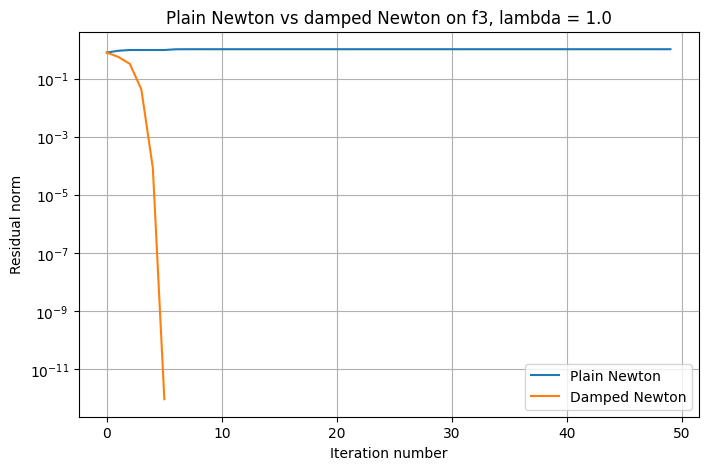

In [21]:
lam = 1.0
x0 = lam * np.ones(n)

x_plain, res_plain, lin_plain = newton_method(
    f3,
    grad3,
    hess3,
    x0,
    tol=1e-8,
    maxit=50,
    cg_tol=1e-10,
    cg_maxit=100
)

x_damped, res_damped, lin_damped, damping, values = damped_newton_method(
    f3,
    grad3,
    hess3,
    x0,
    tol=1e-8,
    maxit=50,
    cg_tol=1e-10,
    cg_maxit=100,
    a=1e-4,
    b=0.5
)

plt.figure(figsize=(8, 5))

plt.semilogy(res_plain, label="Plain Newton")
plt.semilogy(res_damped, label="Damped Newton")

plt.xlabel("Iteration number")
plt.ylabel("Residual norm")
plt.title("Plain Newton vs damped Newton on f3, lambda = 1.0")
plt.legend()
plt.grid(True)
plt.show()

# Final summary

## Newton method

Newton uses gradient and Hessian information.

It solves

\[
\nabla^2 f(x_k)d_k=-\nabla f(x_k)
\]

and then updates

\[
x_{k+1}=x_k+d_k
\]

## What we observed

### Quadratic problem

Newton solves the problem in one Newton iteration.

### Himmelblau function

Newton converges much faster than Malitsky-Mishchenko.

### \(f_3\)

Plain Newton can be unstable for larger starting values.

Reason: the Hessian becomes weak far away from the minimizer.

### \(f_4\)

Newton works better because the extra quadratic term improves curvature.

### Damped Newton

Damped Newton is safer than plain Newton.

It is especially useful when the starting point is far away from the minimizer.

## Simple practical advice

- Use Newton when Hessian information is available and reliable.
- Use damped Newton when the starting point may be far from the minimum.
- Use gradient methods when Hessian computation is too expensive.
- Use CG inside Newton when the Hessian system is large.